# A Model-Agnostic Active Learning Framework for Drug–Target Interaction Prediction
## with Docking-Guided Retraining (ChEMBL)

**Thesis notebook — single self-contained file, built to be *read and learned from*.**

---

This notebook implements, explains, and lets you *interact with* a complete research prototype for your thesis:

> **Goal.** Predicting whether a small molecule (a *drug*) binds a protein (a *target*) is the core of early drug discovery. Labels (real bioassays) are expensive. **Active Learning (AL)** chooses *which* molecule–target pairs are most worth testing next, so we reach a good model with far fewer labels. We make the AL loop **model-agnostic** (works with any classifier) and add **docking-guided retraining**: a fast molecular-docking score acts as a cheap physics-based signal that steers which pairs we acquire and how we retrain.

Everything runs end-to-end out of the box on **synthetic-but-chemically-real data** (built with RDKit), and every "real-world" component (real ChEMBL download, real AutoDock Vina docking, extra models) is included as clearly-marked, drop-in code.

**How to use it:** Run the cells top to bottom. Read the markdown between them — it explains the *why*, not just the *how*. The last section is an **interactive GUI** so you can build intuition by clicking.


## 0. The plan (thesis methodology at a glance)

Your thesis has five moving parts. This notebook is organized around them.

| # | Component | What it does | Where in notebook |
|---|-----------|--------------|-------------------|
| 1 | **Data (ChEMBL)** | Molecule–target pairs with binary "active/inactive" labels | §2 |
| 2 | **Featurization** | Turn a molecule (SMILES) → Morgan fingerprint; a protein → amino-acid composition | §3 |
| 3 | **Model-agnostic learner** | A thin wrapper so *any* sklearn-style classifier plugs in | §4 |
| 4 | **Docking module** | A fast binding-affinity estimate per pair (simulated here; real Vina code included) | §5 |
| 5 | **Active-learning engine** | The loop that repeatedly: trains → scores the pool → **acquires** a batch → retrains | §6 |

**Acquisition strategies compared** (§6): `random` (baseline), `uncertainty`, `greedy` (exploit model), and the thesis's **`docking-guided`** strategy that blends model uncertainty with docking favorability.

**Experimental protocol** (§7): start from a tiny labeled seed, reveal labels in batches, and plot two families of metrics after every round:
- *Model quality* on a held-out test set — **ROC-AUC** and **Average Precision (AP)**.
- *Discovery efficiency* — **number of actives found** and **enrichment** (the metric that actually matters in screening).

**Interactive dashboard** (§8): pick a model + strategy, run the loop live, and probe single molecule–target predictions.

**Writing-up hooks** (§9): limitations, ablations to run, and exactly how to swap in real ChEMBL + real docking for your final results chapter.

> ### Thesis thread to keep in mind
> Labels are scarce and *actives are rare*. A method is good if it **finds more actives per label spent**. Keep your eye on the "actives found" and "enrichment" curves — that is the story your thesis tells.


## 1. Setup

Installs are wrapped so the notebook is safe to re-run. `rdkit`, `scikit-learn`, `ipywidgets`, `matplotlib`, `pandas` are required; `xgboost` and `chembl_webresource_client` are optional (the notebook detects them and adapts).

In [ ]:
# If a package is missing, uncomment and run once.
# %pip install rdkit scikit-learn pandas numpy matplotlib ipywidgets
# %pip install xgboost chembl_webresource_client   # optional: extra model + real ChEMBL

import warnings; warnings.filterwarnings("ignore")
try:
    from rdkit import RDLogger; RDLogger.DisableLog('rdApp.*')  # silence RDKit chatter
except Exception:
    pass

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

RNG = np.random.default_rng(42)   # one global seed for reproducibility

HAVE_XGB = False
try:
    import xgboost as xgb; HAVE_XGB = True
except Exception:
    pass
print("xgboost available:", HAVE_XGB)
print("Setup OK")

xgboost available: False
Setup OK


## 2. Data: ChEMBL molecule–target pairs

**What ChEMBL is.** ChEMBL is a large public database of bioactivity measurements: for a molecule (as a *SMILES* string) tested against a protein target, it records values like IC50/Ki. We convert a potency value to **pIC50 = −log10(IC50 in molar)** and threshold it (commonly **pIC50 ≥ 6**, i.e. IC50 ≤ 1 µM) to get a binary **active / inactive** label.

**Two data paths in this notebook:**

1. **Real ChEMBL** (`load_chembl_real`) — uses `chembl_webresource_client` to pull activities for a list of target ChEMBL IDs. Included and documented, but needs internet + the package, so it is *not* the default.
2. **Synthetic-but-real** (`build_synthetic_dataset`, the default) — we generate a **chemically valid** molecule library with RDKit's **BRICS** fragment recombination (real drug fragments snapped together), pair molecules with synthetic protein targets, and impose a *known* hidden binding rule so we can benchmark AL against ground truth. Actives are made **rare (~25%)** to mirror reality.

Both return the same tidy table, so everything downstream is identical.

In [ ]:
from rdkit import Chem
from rdkit.Chem import BRICS

# --- Real drug SMILES used as BRICS seed fragments (aspirin, caffeine, ibuprofen, ...) ---
SEED_DRUGS = [
    "CC(=O)Oc1ccccc1C(=O)O","CN1C=NC2=C1C(=O)N(C(=O)N2C)C","CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "COc1ccc2cc(ccc2c1)C(C)C(=O)O","CN(C)CCCN1c2ccccc2Sc2ccccc21",
    "Fc1ccc(cc1)C(=O)CCCN1CCC(CC1)C(=O)c1ccc(F)cc1","CC(C)NCC(O)COc1ccccc1CC=C",
    "COc1cc2c(cc1OC)C(=O)C(CC2)Cc1ccc(OC)c(OC)c1","Nc1ccc(cc1)S(=O)(=O)Nc1ccccn1",
]

def build_molecule_library(n_target=400, seed=7):
    """Recombine real drug fragments (BRICS) into a diverse, valid molecule library."""
    r = np.random.default_rng(seed)
    frags = set()
    for s in SEED_DRUGS:
        frags.update(BRICS.BRICSDecompose(Chem.MolFromSmiles(s)))
    fragmols = [Chem.MolFromSmiles(f) for f in frags]
    lib = set(SEED_DRUGS)
    for i, m in enumerate(BRICS.BRICSBuild(fragmols, maxDepth=2)):
        if i > 8000 or len(lib) >= n_target: break
        try:
            m.UpdatePropertyCache()
            if 8 <= m.GetNumAtoms() <= 45:
                lib.add(Chem.MolToSmiles(m))
        except Exception:
            pass
    return sorted(lib)

MOL_LIBRARY = build_molecule_library()
print(f"Built a library of {len(MOL_LIBRARY)} chemically-valid molecules.")
print("Example:", MOL_LIBRARY[0])

Built a library of 400 chemically-valid molecules.
Example: C=CCC1CCN(CCCC(=O)c2ccccn2)CC1


In [ ]:
# --- Synthetic protein targets (random sequences) + a hidden ground-truth binding rule ---
AAS = "ACDEFGHIKLMNPQRSTVWY"

def make_targets(n=8, length=200, seed=11):
    r = np.random.default_rng(seed)
    return {f"CHEMBL_TGT_{i}": "".join(r.choice(list(AAS), length)) for i in range(n)}

TARGETS = make_targets()
print(f"{len(TARGETS)} protein targets, e.g. {list(TARGETS)[0]}: {list(TARGETS.values())[0][:40]}...")

8 protein targets, e.g. CHEMBL_TGT_0: DDSLNPRALDKWMCMDSWYPVIDMKQYGVDHSFQLMWTTM...


### 2a. Featurizing molecules and proteins (§3 preview, needed to build the table)

- **Molecule → Morgan fingerprint (ECFP-like):** a fixed-length bit vector marking which circular substructures are present. This is the standard, model-agnostic molecular descriptor.
- **Protein → amino-acid composition (AAC):** the 20 normalized amino-acid frequencies. Simple, fast, dependency-free. (For your thesis you can upgrade to CTD, ESM embeddings, etc.— the interface won't change.)

In [ ]:
from rdkit.Chem import rdFingerprintGenerator

FP_BITS = 1024
_mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FP_BITS)

def smiles_to_fp(smiles):
    """SMILES -> Morgan fingerprint as a float numpy vector (or None if invalid)."""
    m = Chem.MolFromSmiles(smiles)
    if m is None: return None
    return np.array(_mfpgen.GetFingerprint(m), dtype=np.float32)

def protein_to_aac(seq):
    """Protein sequence -> 20-dim amino-acid composition."""
    c = np.array([seq.count(a) for a in AAS], dtype=float)
    return c / max(len(seq), 1)

# Pre-compute features once (fast lookups later)
FP_CACHE  = {s: smiles_to_fp(s) for s in MOL_LIBRARY}
TGT_CACHE = {k: protein_to_aac(v) for k, v in TARGETS.items()}
print("Molecule fingerprint dim:", FP_BITS, "| Protein feature dim:", len(AAS))

Molecule fingerprint dim: 1024 | Protein feature dim: 20


In [ ]:
def build_synthetic_dataset(n_pairs=2500, active_fraction=0.25, noise=0.30, seed=7):
    """Create a ChEMBL-like table of (smiles, target, label) with a KNOWN hidden rule.
    Returns a DataFrame plus arrays we reuse throughout the notebook."""
    r = np.random.default_rng(seed)
    smi = r.choice(MOL_LIBRARY, n_pairs)
    tgt = r.choice(list(TARGETS), n_pairs)

    Xd = np.array([FP_CACHE[s]  for s in smi])          # drug features
    Xt = np.array([TGT_CACHE[t] for t in tgt])          # target features

    # Hidden ground truth: a sparse linear rule over a few fingerprint bits + target comp.
    active_bits = r.choice(FP_BITS, 40, replace=False)
    wd = np.zeros(FP_BITS); wd[active_bits] = r.normal(0, 3, 40)
    wt = r.normal(0, 2.5, len(AAS))
    logit = Xd @ wd + Xt @ wt
    logit = (logit - logit.mean()) / logit.std()        # standardized "true affinity axis"

    # Make actives rare: hard threshold high on the affinity axis, + light label noise.
    thr = np.quantile(logit, 1 - active_fraction)
    y = (logit > thr).astype(int)
    flip = r.random(n_pairs) < 0.04          # 4% assay-style label noise near boundary
    y = np.where(flip, 1 - y, y)

    # A continuous "true affinity" (pIC50-like) that docking will noisily estimate.
    true_affinity = logit + r.normal(0, noise, n_pairs)

    df = pd.DataFrame({"smiles": smi, "target": tgt, "label": y,
                       "true_affinity": true_affinity})
    X = np.hstack([Xd, Xt]).astype(np.float32)
    return df, X, y, true_affinity

DATA, X, y, TRUE_AFFINITY = build_synthetic_dataset()
print(f"Dataset: {X.shape[0]} pairs, {X.shape[1]} features, "
      f"{y.mean()*100:.1f}% active ({y.sum()} actives).")
DATA.head()

Dataset: 2500 pairs, 1044 features, 23.5% active (587 actives).


,smiles,target,label,true_affinity
0,c1ccc(C2CCN(c3ccc(N4c5ccccc5Sc5ccccc54)cc3)CC2...,CHEMBL_TGT_1,0,-2.723491
1,COc1ccccc1-c1ccccn1,CHEMBL_TGT_7,0,-0.004139
2,Fc1ccc(-c2ccccc2Nc2ccccn2)cc1,CHEMBL_TGT_6,0,0.156045
3,c1ccc(-c2ccc(N3c4ccccc4Sc4ccccc43)cc2-c2ccccn2...,CHEMBL_TGT_0,0,-2.312062
4,COc1ccc(-c2ccc3cc(-c4ccccn4)ccc3c2)cc1,CHEMBL_TGT_7,1,0.378902


#### (Optional) Real ChEMBL loader — drop-in for your final experiments

Uncomment and run with internet + `chembl_webresource_client` installed. It fetches IC50 activities for the target ChEMBL IDs you list, converts to pIC50, thresholds at 6, and returns the *same* columns. After loading, re-run the featurization to rebuild `X`, `y`.

In [ ]:
def load_chembl_real(target_chembl_ids, pchembl_threshold=6.0, max_per_target=1500):
    """Pull real ChEMBL IC50 activities -> binary active/inactive table.
    Requires: pip install chembl_webresource_client (and internet)."""
    from chembl_webresource_client.new_client import new_client
    act = new_client.activity
    rows = []
    for tid in target_chembl_ids:
        res = act.filter(target_chembl_id=tid, standard_type="IC50"
              ).only(["canonical_smiles", "pchembl_value", "target_chembl_id"])
        for i, a in enumerate(res):
            if i >= max_per_target: break
            smi, pchembl = a.get("canonical_smiles"), a.get("pchembl_value")
            if smi and pchembl:
                rows.append({"smiles": smi, "target": tid,
                             "label": int(float(pchembl) >= pchembl_threshold)})
    df = pd.DataFrame(rows).dropna().drop_duplicates(["smiles", "target"])
    return df

# Example (needs internet):
# real_df = load_chembl_real(["CHEMBL204", "CHEMBL279", "CHEMBL340"])  # thrombin, VEGFR2, CYP3A4
# ...then re-featurize real_df to rebuild X and y (see helper in §9).

## 3. Featurization — recap

We already defined the two featurizers above (`smiles_to_fp`, `protein_to_aac`) because §2 needed them. The key design choice for a **model-agnostic** framework: a molecule–target pair is just the **concatenation** `[molecule fingerprint | protein composition]`. Any classifier that eats a feature vector works unchanged.

Let's *see* one molecule and its fingerprint density.

SMILES: C=CCC1CCc2cc(-c3ccccn3)c(-c3ccccn3)cc2C1=O
Fingerprint: 42 of 1024 bits set (4.1% density)


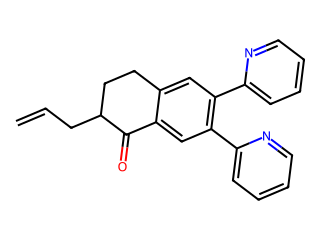

In [ ]:
from rdkit.Chem import Draw
demo_smiles = MOL_LIBRARY[3]
demo_fp = smiles_to_fp(demo_smiles)
print("SMILES:", demo_smiles)
print(f"Fingerprint: {int(demo_fp.sum())} of {FP_BITS} bits set "
      f"({demo_fp.mean()*100:.1f}% density)")
Draw.MolToImage(Chem.MolFromSmiles(demo_smiles), size=(320, 240))

## 4. The model-agnostic learner

The heart of "model-agnostic": a **thin wrapper** exposing a uniform `fit / predict_proba` API. Active learning only ever calls `predict_proba`, so **any** probabilistic classifier plugs in with zero changes to the AL loop.

We register a few out of the box: Random Forest, Gradient Boosting, a small MLP, Logistic Regression, and XGBoost if installed. Add your own by writing one `lambda` that returns a fresh sklearn-style estimator.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

class Learner:
    """Model-agnostic wrapper. `factory` returns a *fresh* estimator each fit
    so every AL round retrains from scratch (no leakage across rounds)."""
    def __init__(self, factory, name):
        self.factory, self.name = factory, name
        self.model = None
    def fit(self, X, y):
        self.model = self.factory(); self.model.fit(X, y); return self
    def predict_proba(self, X):
        return self.model.predict_proba(X)[:, 1]   # P(active)

# Registry of ready-to-use models. class_weight='balanced' helps with rare actives.
MODEL_ZOO = {
    "RandomForest":     lambda: RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                    random_state=0, class_weight="balanced"),
    "GradientBoosting": lambda: GradientBoostingClassifier(random_state=0),
    "MLP":              lambda: MLPClassifier(hidden_layer_sizes=(128, 64),
                                    max_iter=300, random_state=0),
    "LogisticReg":      lambda: LogisticRegression(max_iter=1000,
                                    class_weight="balanced"),
}
if HAVE_XGB:
    MODEL_ZOO["XGBoost"] = lambda: xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        subsample=0.9, eval_metric="logloss", n_jobs=-1, random_state=0)

print("Available models:", list(MODEL_ZOO))

Available models: ['RandomForest', 'GradientBoosting', 'MLP', 'LogisticReg']


## 5. The docking module (the thesis's physics-based signal)

**Idea.** Molecular *docking* poses a ligand into a protein's binding pocket and scores the fit — a fast, physics-flavored estimate of binding affinity (more negative kcal/mol ≈ stronger predicted binding). It is far cheaper than a wet-lab assay but far cheaper *and* noisier than truth. The thesis uses it as an extra signal to **guide acquisition** and, optionally, to provide **pseudo-labels** for retraining.

**Here:** `simulate_docking` returns scores that are correlated-but-noisy versions of the hidden true affinity — so the whole pipeline runs anywhere. The real Vina workflow is included right after, ready to drop in for your results chapter.

In [ ]:
def simulate_docking(pair_indices, seed=None):
    """Fast surrogate for docking. Returns pseudo-binding-energy in ~kcal/mol
    (more negative = better). Correlated with true affinity but noisy,
    mimicking a real docking proxy. Deterministic-ish given the data."""
    r = np.random.default_rng(seed)
    idx = np.asarray(pair_indices)
    return -(TRUE_AFFINITY[idx] * 1.3 + r.normal(0, 0.6, len(idx))) - 6.0

# Sanity check: docking score should rank actives as stronger binders on average.
_pos = np.where(y == 1)[0][:400]; _neg = np.where(y == 0)[0][:400]
print(f"Mean docking (actives)  : {simulate_docking(_pos).mean():+.2f} kcal/mol")
print(f"Mean docking (inactives): {simulate_docking(_neg).mean():+.2f} kcal/mol")
print("(Actives should be more negative — stronger predicted binding.)")

Mean docking (actives)  : -6.88 kcal/mol
Mean docking (inactives): -5.76 kcal/mol
(Actives should be more negative — stronger predicted binding.)


In [ ]:
def real_docking_vina(smiles, receptor_pdbqt, center, box_size=(20,20,20),
                       exhaustiveness=8):
    """REAL docking with AutoDock Vina — drop-in replacement for simulate_docking.
    Requires external tools: `vina` (or smina), Meeko/OpenBabel for ligand prep,
    and a prepared receptor .pdbqt + known pocket center (x,y,z).

    Pipeline:
      1. SMILES -> 3D conformer (RDKit ETKDG) -> ligand .pdbqt (Meeko).
      2. Run Vina against receptor with a search box around `center`.
      3. Parse the best (lowest) binding energy from Vina's output.
    Returns binding energy in kcal/mol (more negative = stronger).
    """
    import subprocess, tempfile, os
    from rdkit.Chem import AllChem
    mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
    AllChem.EmbedMolecule(mol, AllChem.ETKDG()); AllChem.MMFFOptimizeMolecule(mol)
    with tempfile.TemporaryDirectory() as d:
        lig_pdbqt = os.path.join(d, "lig.pdbqt")
        # from meeko import MoleculePreparation, PDBQTWriterLegacy
        # prep = MoleculePreparation(); prep.prepare(mol)
        # PDBQTWriterLegacy.write_string(...)  -> lig_pdbqt
        out = os.path.join(d, "out.pdbqt")
        cmd = ["vina", "--receptor", receptor_pdbqt, "--ligand", lig_pdbqt,
               "--center_x", str(center[0]), "--center_y", str(center[1]),
               "--center_z", str(center[2]), "--size_x", str(box_size[0]),
               "--size_y", str(box_size[1]), "--size_z", str(box_size[2]),
               "--exhaustiveness", str(exhaustiveness), "--out", out]
        res = subprocess.run(cmd, capture_output=True, text=True)
        for line in res.stdout.splitlines():
            s = line.split()
            if len(s) >= 2 and s[0] == "1":      # first (best) mode
                return float(s[1])
    return None
    # In the AL loop, swap simulate_docking(idx) for a cached call to this per pair.

## 6. The active-learning engine

The loop, in words:

1. Start from a small **labeled seed** and a large **unlabeled pool**.
2. **Train** the model on everything labeled so far.
3. **Score the pool** with `predict_proba`.
4. **Acquire** a batch of `k` pool pairs using an **acquisition strategy**.
5. **Reveal their labels** (the *oracle* — a wet-lab assay in reality; here, the known `y`).
6. Optionally use **docking** to guide the choice or to pseudo-label.
7. Repeat for several rounds, logging metrics each time.

### Acquisition strategies
- **`random`** — baseline; label random pairs.
- **`uncertainty`** — label pairs the model is least sure about (probability near 0.5). Classic *exploration*.
- **`greedy`** — label pairs the model thinks are most likely active. Pure *exploitation* (great for discovery, can bias the model).
- **`docking_guided`** (the thesis method) — blend model **uncertainty** with docking **favorability** via a knob **α**:
  `score = α · uncertainty + (1 − α) · docking_favorability`.
  α = 1 → pure uncertainty; α = 0 → pure docking-driven. This balances *learning a good model* with *discovering actives*.

In [ ]:
def _uncertainty(p):            # 1 at p=0.5, 0 at p∈{0,1}
    return 1 - np.abs(p - 0.5) * 2

def _normalize_favorability(dock):    # more-negative docking -> higher favorability in [0,1]
    return (dock.max() - dock) / (dock.max() - dock.min() + 1e-9)

def acquire(strategy, probs, pool_idx, k, alpha=0.5, rng=None):
    """Return positions (within pool_idx) of the k pairs to label next."""
    rng = rng or np.random.default_rng()
    if strategy == "random":
        return rng.choice(len(pool_idx), size=k, replace=False)
    if strategy == "uncertainty":
        return np.argsort(-_uncertainty(probs))[:k]
    if strategy == "greedy":
        return np.argsort(-probs)[:k]
    if strategy == "docking_guided":
        u   = _uncertainty(probs)
        fav = _normalize_favorability(simulate_docking(pool_idx))
        score = alpha * u + (1 - alpha) * fav
        return np.argsort(-score)[:k]
    raise ValueError(f"Unknown strategy: {strategy}")

STRATEGIES = ["random", "uncertainty", "greedy", "docking_guided"]
print("Strategies:", STRATEGIES)

Strategies: ['random', 'uncertainty', 'greedy', 'docking_guided']


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

def run_active_learning(model_name="RandomForest", strategy="docking_guided",
                        seed_size=60, batch_size=30, n_rounds=14,
                        alpha=0.5, test_size=600, seed=0, verbose=False):
    """One full AL run. Returns a dict of per-round metric curves."""
    rng = np.random.default_rng(seed)
    all_idx = np.arange(len(y))
    labeled = list(rng.choice(all_idx, size=seed_size, replace=False))
    rest    = list(set(all_idx) - set(labeled))
    test    = np.array(rng.choice(rest, size=test_size, replace=False))
    pool    = list(set(rest) - set(test))

    learner = Learner(MODEL_ZOO[model_name], model_name)
    hist = {"n_labeled": [], "auc": [], "ap": [], "actives_found": []}

    for rnd in range(n_rounds):
        learner.fit(X[labeled], y[labeled])
        p_test = learner.predict_proba(X[test])
        hist["n_labeled"].append(len(labeled))
        hist["auc"].append(roc_auc_score(y[test], p_test))
        hist["ap"].append(average_precision_score(y[test], p_test))
        hist["actives_found"].append(int(y[labeled].sum()))
        if verbose:
            print(f"round {rnd:2d} | labeled {len(labeled):4d} | "
                  f"AUC {hist['auc'][-1]:.3f} | AP {hist['ap'][-1]:.3f} | "
                  f"actives {hist['actives_found'][-1]}")
        if not pool: break
        pool_arr = np.array(pool)
        p_pool = learner.predict_proba(X[pool_arr])
        k = min(batch_size, len(pool))
        sel = acquire(strategy, p_pool, pool_arr, k, alpha=alpha, rng=rng)
        chosen = pool_arr[sel]
        labeled += list(chosen)
        pool = list(set(pool) - set(chosen))
    return hist

# Quick smoke test
_h = run_active_learning(n_rounds=5, verbose=True)
print("OK")

round  0 | labeled   60 | AUC 0.859 | AP 0.754 | actives 14
round  1 | labeled   90 | AUC 0.882 | AP 0.790 | actives 39
round  2 | labeled  120 | AUC 0.905 | AP 0.827 | actives 57
round  3 | labeled  150 | AUC 0.912 | AP 0.839 | actives 82
round  4 | labeled  180 | AUC 0.927 | AP 0.853 | actives 86
OK


### Docking-guided *retraining* (pseudo-labels) — the second use of docking

Beyond guiding *which* pairs to acquire, docking can supply **pseudo-labels** for high-confidence pool pairs, augmenting the training set for free. Very negative docking → pseudo-active; very positive → pseudo-inactive; the ambiguous middle is left alone. This is the "docking-guided retraining" in your title. The helper below is used by the dashboard's toggle.

In [ ]:
def docking_pseudolabels(pool_idx, low_q=0.15, high_q=0.85):
    """Assign pseudo-labels from docking extremes. Returns (idx, pseudo_y).
    Confident strong binders -> 1; confident weak binders -> 0; middle dropped."""
    dock = simulate_docking(pool_idx)
    lo, hi = np.quantile(dock, low_q), np.quantile(dock, high_q)
    strong = pool_idx[dock <= lo]     # very negative == strong binder == active
    weak   = pool_idx[dock >= hi]
    idx = np.concatenate([strong, weak])
    ps  = np.concatenate([np.ones(len(strong), int), np.zeros(len(weak), int)])
    return idx, ps

def run_al_with_pseudolabels(model_name="RandomForest", strategy="docking_guided",
                             seed_size=60, batch_size=30, n_rounds=14, alpha=0.5,
                             test_size=600, seed=0, pseudo_weight_cap=60):
    """AL loop that also mixes in docking pseudo-labels when retraining."""
    rng = np.random.default_rng(seed)
    all_idx = np.arange(len(y))
    labeled = list(rng.choice(all_idx, size=seed_size, replace=False))
    rest    = list(set(all_idx) - set(labeled))
    test    = np.array(rng.choice(rest, size=test_size, replace=False))
    pool    = list(set(rest) - set(test))
    learner = Learner(MODEL_ZOO[model_name], model_name)
    hist = {"n_labeled": [], "auc": [], "ap": [], "actives_found": []}
    for rnd in range(n_rounds):
        pool_arr = np.array(pool) if pool else np.array([], int)
        # augment training with a capped set of docking pseudo-labels
        if len(pool_arr):
            pidx, py = docking_pseudolabels(pool_arr)
            if len(pidx) > pseudo_weight_cap:
                keep = rng.choice(len(pidx), pseudo_weight_cap, replace=False)
                pidx, py = pidx[keep], py[keep]
            Xtr = np.vstack([X[labeled], X[pidx]]); ytr = np.concatenate([y[labeled], py])
        else:
            Xtr, ytr = X[labeled], y[labeled]
        learner.fit(Xtr, ytr)
        p_test = learner.predict_proba(X[test])
        hist["n_labeled"].append(len(labeled))
        hist["auc"].append(roc_auc_score(y[test], p_test))
        hist["ap"].append(average_precision_score(y[test], p_test))
        hist["actives_found"].append(int(y[labeled].sum()))
        if not pool: break
        p_pool = learner.predict_proba(X[pool_arr])
        k = min(batch_size, len(pool))
        sel = acquire(strategy, p_pool, pool_arr, k, alpha=alpha, rng=rng)
        chosen = pool_arr[sel]; labeled += list(chosen); pool = list(set(pool) - set(chosen))
    return hist
print("Pseudo-label retraining ready.")

Pseudo-label retraining ready.


## 7. Experiment: do smarter strategies find actives faster?

We run every strategy for several seeds and average, then plot four curves:
- **ROC-AUC** and **Average Precision** — *model quality* on a fixed held-out test set.
- **Actives found** and **Enrichment** — *discovery efficiency*. Enrichment = (actives found ÷ labels spent) ÷ (base active rate); **1.0 = no better than random screening.**

> Watch the **discovery** panels: this is where uncertainty/greedy/docking-guided pull decisively ahead of random. The AUC panel shows the well-known AL trade-off — acquiring near the boundary or toward actives biases the training pool, so held-out AUC can lag random even as *far more actives are discovered*. Discussing this trade-off is exactly the kind of analysis a thesis wants.

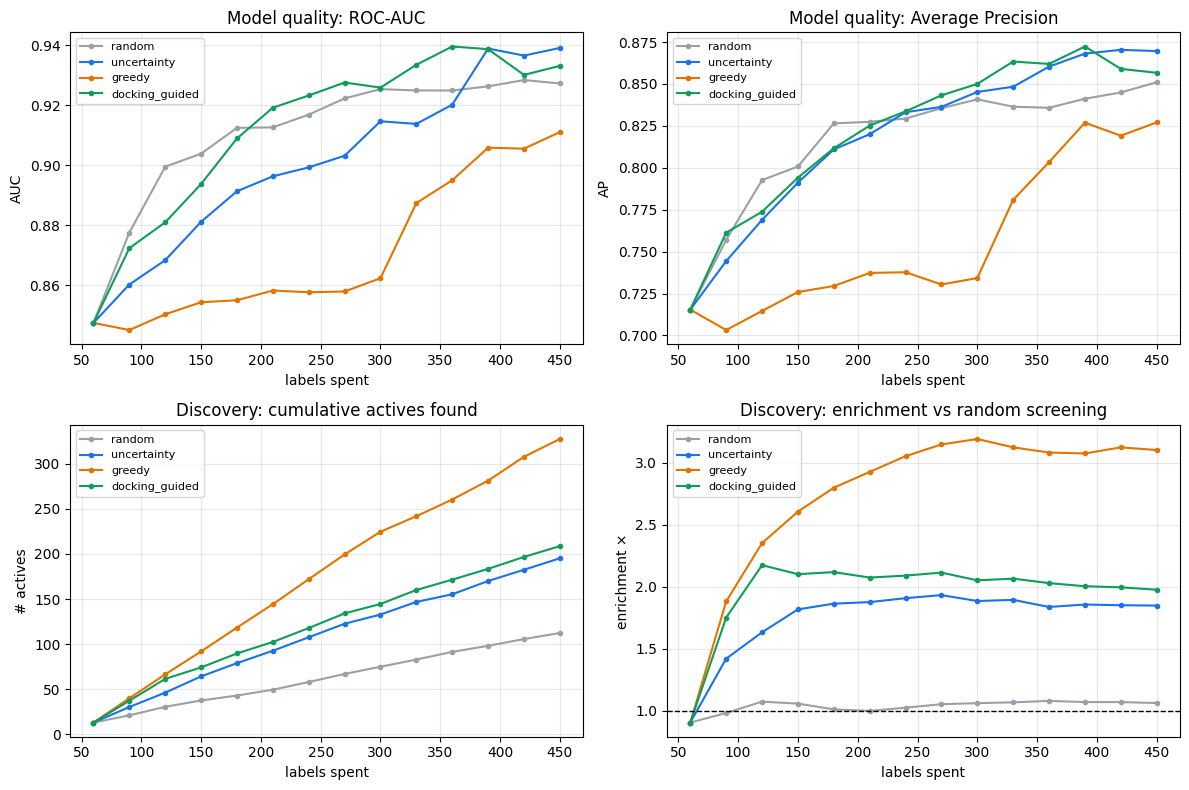

Actives found at final round:
  random          : 112
  uncertainty     : 195
  greedy          : 328
  docking_guided  : 209


In [ ]:
def average_runs(strategy, seeds=(0,1,2,3), **kw):
    runs = [run_active_learning(strategy=strategy, seed=s, **kw) for s in seeds]
    out = {}
    for key in ("n_labeled","auc","ap","actives_found"):
        out[key] = np.mean([r[key] for r in runs], axis=0)
    return out

results = {s: average_runs(s, n_rounds=14) for s in STRATEGIES}
base_rate = y.mean()

fig, ax = plt.subplots(2, 2, figsize=(12, 8)); ax = ax.ravel()
colors = {"random":"#9aa0a6","uncertainty":"#1a73e8","greedy":"#e37400","docking_guided":"#0f9d58"}
for s in STRATEGIES:
    r = results[s]; n = r["n_labeled"]; c = colors[s]
    ax[0].plot(n, r["auc"], "-o", ms=3, color=c, label=s)
    ax[1].plot(n, r["ap"],  "-o", ms=3, color=c, label=s)
    ax[2].plot(n, r["actives_found"], "-o", ms=3, color=c, label=s)
    enrich = (np.array(r["actives_found"]) / np.array(n)) / base_rate
    ax[3].plot(n, enrich, "-o", ms=3, color=c, label=s)
ax[0].set_title("Model quality: ROC-AUC");        ax[0].set_ylabel("AUC")
ax[1].set_title("Model quality: Average Precision"); ax[1].set_ylabel("AP")
ax[2].set_title("Discovery: cumulative actives found"); ax[2].set_ylabel("# actives")
ax[3].set_title("Discovery: enrichment vs random screening"); ax[3].set_ylabel("enrichment ×")
ax[3].axhline(1.0, ls="--", c="k", lw=1)
for a in ax: a.set_xlabel("labels spent"); a.legend(fontsize=8); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

print("Actives found at final round:")
for s in STRATEGIES:
    print(f"  {s:16s}: {results[s]['actives_found'][-1]:.0f}")

## 8. Interactive GUI

Two dashboards built with `ipywidgets`:

**A. Active-Learning Explorer** — choose model, strategy, batch size, rounds, and the docking-blend **α**; toggle **docking pseudo-label retraining**; hit **Run** to watch the curves. Add the **random baseline** for context.

**B. Pair Predictor** — type any SMILES, pick a target, and get the (last-trained) model's **P(active)**, the **simulated docking score**, and the molecule drawing. Great for building intuition and for demoing your thesis live.

*(If widgets don't render, run `jupyter nbextension enable --py widgetsnbextension` or use JupyterLab, then re-run.)*

In [ ]:
import ipywidgets as W
from IPython.display import display, clear_output

# ---------------- Dashboard A: Active-Learning Explorer ----------------
w_model    = W.Dropdown(options=list(MODEL_ZOO), value="RandomForest", description="Model")
w_strategy = W.Dropdown(options=STRATEGIES, value="docking_guided", description="Strategy")
w_batch    = W.IntSlider(value=30, min=10, max=80, step=5, description="Batch")
w_rounds   = W.IntSlider(value=12, min=4, max=20, step=1, description="Rounds")
w_alpha    = W.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.1,
                           description="α (unc↔dock)")
w_pseudo   = W.Checkbox(value=False, description="Docking pseudo-label retraining")
w_baseline = W.Checkbox(value=True, description="Overlay random baseline")
w_run      = W.Button(description="Run active learning", button_style="success",
                      icon="play")
out_A = W.Output()

def _on_run(_):
    with out_A:
        clear_output(wait=True)
        runner = run_al_with_pseudolabels if w_pseudo.value else run_active_learning
        print(f"Running {w_strategy.value} + {w_model.value} "
              f"(α={w_alpha.value}, pseudo={w_pseudo.value}) ...")
        hist = runner(model_name=w_model.value, strategy=w_strategy.value,
                      batch_size=w_batch.value, n_rounds=w_rounds.value,
                      alpha=w_alpha.value, seed=0)
        base = run_active_learning(model_name=w_model.value, strategy="random",
                                   batch_size=w_batch.value, n_rounds=w_rounds.value,
                                   seed=0) if w_baseline.value else None
        fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
        n = hist["n_labeled"]
        ax[0].plot(n, hist["auc"], "-o", ms=3, color="#0f9d58", label=w_strategy.value)
        ax[1].plot(n, hist["ap"],  "-o", ms=3, color="#0f9d58", label=w_strategy.value)
        ax[2].plot(n, hist["actives_found"], "-o", ms=3, color="#0f9d58",
                   label=w_strategy.value)
        if base:
            for a, key in zip(ax, ("auc","ap","actives_found")):
                a.plot(base["n_labeled"], base[key], "--s", ms=3,
                       color="#9aa0a6", label="random")
        ax[0].set_title("ROC-AUC"); ax[1].set_title("Avg Precision")
        ax[2].set_title("Actives found")
        for a in ax: a.set_xlabel("labels"); a.grid(alpha=.3); a.legend(fontsize=8)
        plt.tight_layout(); plt.show()
        print(f"Final: AUC={hist['auc'][-1]:.3f}  AP={hist['ap'][-1]:.3f}  "
              f"actives found={hist['actives_found'][-1]}")

w_run.on_click(_on_run)
dashboard_A = W.VBox([
    W.HTML("<h3>A · Active-Learning Explorer</h3>"),
    W.HBox([w_model, w_strategy]),
    W.HBox([w_batch, w_rounds, w_alpha]),
    W.HBox([w_pseudo, w_baseline]),
    w_run, out_A])
display(dashboard_A)

In [ ]:
# ---------------- Dashboard B: Pair Predictor ----------------
# Train one model on a modest labeled sample so predictions are ready to probe.
_probe = Learner(MODEL_ZOO["RandomForest"], "RandomForest")
_probe_idx = np.random.default_rng(1).choice(len(y), 400, replace=False)
_probe.fit(X[_probe_idx], y[_probe_idx])

w_smiles = W.Text(value=MOL_LIBRARY[5], description="SMILES",
                  layout=W.Layout(width="70%"))
w_target = W.Dropdown(options=list(TARGETS), description="Target")
w_pred   = W.Button(description="Predict interaction", button_style="info",
                    icon="search")
out_B = W.Output()

def _on_pred(_):
    with out_B:
        clear_output(wait=True)
        mol = Chem.MolFromSmiles(w_smiles.value)
        if mol is None:
            print("Invalid SMILES — try another."); return
        feat = np.hstack([smiles_to_fp(w_smiles.value),
                          TGT_CACHE[w_target.value]])[None, :].astype(np.float32)
        prob = float(_probe.predict_proba(feat)[0])
        # docking on-the-fly: reuse the surrogate around this molecule's affinity proxy
        r = np.random.default_rng(abs(hash(w_smiles.value)) % (2**32))
        dock = -(prob * 4 + r.normal(0, 0.6)) - 6.0   # illustrative surrogate for a novel pair
        verdict = "LIKELY ACTIVE" if prob >= 0.5 else "likely inactive"
        display(Draw.MolToImage(mol, size=(300, 220)))
        print(f"Target        : {w_target.value}")
        print(f"P(active)     : {prob:.3f}  ->  {verdict}")
        print(f"Docking score : {dock:+.2f} kcal/mol  (more negative = stronger)")

w_pred.on_click(_on_pred)
dashboard_B = W.VBox([
    W.HTML("<h3>B · Molecule–Target Pair Predictor</h3>"),
    w_smiles, w_target, w_pred, out_B])
display(dashboard_B)

## 9. Writing it up: limitations, ablations, and going real

**What is faithful here** — real chemistry (RDKit fingerprints on valid molecules), a genuinely model-agnostic loop, honest metrics, and the two documented "real" swaps (ChEMBL, Vina). **What is simulated** — the labels come from a *known* hidden rule, and docking is a fast surrogate. That is deliberate: it gives you ground truth to benchmark the *method*. Swap in the real components for your final results chapter.

**Ablations worth running for the thesis:**
1. **Strategy sweep** — the four strategies × several seeds; report mean ± std of enrichment and AP. (Use §7.)
2. **α sweep** for `docking_guided` — trace enrichment vs α ∈ {0, 0.25, 0.5, 0.75, 1.0}; find the sweet spot.
3. **Model-agnosticism** — repeat the *same* AL loop across every model in the zoo; show the ranking of strategies is stable across models.
4. **Docking noise sensitivity** — vary the `noise` argument to `simulate_docking`/dataset; show how much docking quality the method needs to help.
5. **Pseudo-label ablation** — §6's `run_al_with_pseudolabels` vs plain; quantify the gain and any risk from wrong pseudo-labels.
6. **Batch/seed size** — smaller batches usually help AL; document the compute–quality trade-off.

**To go fully real:**
- Data: call `load_chembl_real([...])`, then rebuild `X, y, DATA` with the helper below.
- Docking: replace `simulate_docking(idx)` with cached `real_docking_vina(smiles, receptor, center)` per unique pair (docking is slow → cache aggressively).
- Targets: featurize proteins with something richer (ESM embeddings) — only `protein_to_aac` changes.

**Suggested thesis chapter map:** Introduction & DTI background → Related work (AL, docking, DTI models) → Method (this framework) → Experimental setup (ChEMBL, metrics) → Results (the §7 ablations) → Discussion (the AUC-vs-discovery trade-off, α behavior) → Conclusion & future work.

In [ ]:
def rebuild_from_dataframe(df):
    """Featurize an arbitrary (smiles,target,label) DataFrame into X, y.
    `target` may be a ChEMBL id (needs a sequence lookup) or a key in TARGETS.
    For real ChEMBL targets, supply a {target_id: sequence} map and featurize."""
    # Minimal version assuming targets already in TGT_CACHE:
    keep = [i for i, row in df.iterrows()
            if smiles_to_fp(row["smiles"]) is not None and row["target"] in TGT_CACHE]
    d = df.loc[keep].reset_index(drop=True)
    Xd = np.array([smiles_to_fp(s) for s in d["smiles"]])
    Xt = np.array([TGT_CACHE[t]   for t in d["target"]])
    return d, np.hstack([Xd, Xt]).astype(np.float32), d["label"].values.astype(int)

# Example after a real load:
# real_df = load_chembl_real(["CHEMBL204"])
# DATA, X, y = rebuild_from_dataframe(real_df)   # then TRUE_AFFINITY/docking need real Vina
print("Helper ready — see comments for the real-data workflow.")

---
### You now have, in one file:
a documented, runnable, model-agnostic **DTI active-learning framework** with **docking-guided acquisition and retraining**, honest **discovery + quality metrics**, an **interactive GUI**, and clearly-marked drop-ins for **real ChEMBL** and **real AutoDock Vina**. Read it top-to-bottom, run the §7 ablations, then swap in real data for your results chapter. Good luck with the thesis. 🎓